In [62]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
df_transactions = pd.read_csv('./data/cleaned_data/transactions.csv')
display(df_transactions.head())

,Unique ID,Transaction Date,Subscription Status,Payee Name,Payment Source,Product,Certificate Voyage,Payment Amount,Transaction Fee,Net Payment,Refund Amount,Credits Purchased
0,d41d8cd98f00b204e9800998ecf8427e,NaN,Unknown,Unkown,Unknown,Unknown,No Certificate,0.0,0.0,0.0,0.0,0.0
1,fff1b532fb511f1ade207c7f213b1937,NaN,Active,Unkown,Unknown,Unknown,No Certificate,0.0,0.0,0.0,0.0,0.0
2,fd9cde9bdb0957f27b1421d2fa34d132,NaN,Active,Unkown,Unknown,Unknown,No Certificate,0.0,0.0,0.0,0.0,0.0
3,dadffe486c63fc05d8b3afee2c4dc132,NaN,Active,Unkown,Unknown,Unknown,No Certificate,0.0,0.0,0.0,0.0,0.0
4,d41d8cd98f00b204e9800998ecf8427e,NaN,Unknown,Unkown,DISCORD,Unknown,No Certificate,0.0,0.0,0.0,0.0,0.0


In [63]:
# Examine the shape of the data
print(f"Shape of the DataFrame: {df_transactions.shape}")

# Inspect Data Types
print("\nData Types of Columns:")
print(df_transactions.dtypes)

# Summarize Numerical Features
print("\nDescriptive Statistics for Numerical Features:")
print(df_transactions.describe())

# Explore Categorical Features
print("\nUnique Values and Frequencies for Categorical Features:")
for column in df_transactions.select_dtypes(include=['object']):
    print(f"\nColumn: {column}")
    print(df_transactions[column].value_counts())

# Check for Missing Values
print("\nMissing Values:")
print(df_transactions.isnull().sum())
print("\nProportion of Missing Values:")
print(df_transactions.isnull().mean())

# Preliminary Insights
print("\nPreliminary Insights:")
# Analyze the results from the previous steps to gain preliminary insights about the data
# ... (This part requires manual inspection and interpretation of the output)

Shape of the DataFrame: (886, 12)

Data Types of Columns:
Unique ID               object
Transaction Date        object
Subscription Status     object
Payee Name              object
Payment Source          object
Product                 object
Certificate Voyage      object
Payment Amount         float64
Transaction Fee        float64
Net Payment            float64
Refund Amount          float64
Credits Purchased      float64
dtype: object

Descriptive Statistics for Numerical Features:
       Payment Amount  Transaction Fee  Net Payment  Refund Amount  \
count      886.000000       886.000000   886.000000          886.0   
mean         8.283973         0.502630     7.781343            0.0   
std         20.250201         0.520025    19.961883            0.0   
min          0.000000         0.000000    -0.300000            0.0   
25%          2.990000         0.300000     2.690000            0.0   
50%          2.990000         0.390000     2.690000            0.0   
75%          5.000

In [64]:
# Handle missing values
print("Missing values before handling:")
print(df_transactions.isnull().sum())

# Replace missing values in 'Transaction Date' with a placeholder or the most frequent date (depending on the context)
df_transactions['Transaction Date'].fillna('Unknown', inplace=True)

# Replace missing values in numerical columns with the mean (or median)
numerical_cols = ['Transaction Fee', 'Net Payment', 'Refund Amount', 'Credits Purchased']  # Add other relevant numerical columns
for col in numerical_cols:
    df_transactions[col].fillna(df_transactions[col].mean(), inplace=True)  # Or use median: df_transactions[col].median()

# Replace missing values in categorical columns with 'Unknown' (or the most frequent value)
categorical_cols = ['Payee Name', 'Product']  # Add other relevant categorical columns
for col in categorical_cols:
    df_transactions[col].fillna('Unknown', inplace=True)  # Or use: df_transactions[col].mode()[0]

for col in numerical_cols:  # Use the same numerical_cols as above
    Q1 = df_transactions[col].quantile(0.25)
    Q3 = df_transactions[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_transactions = df_transactions[(df_transactions[col] >= lower_bound) & (df_transactions[col] <= upper_bound)]

for col in categorical_cols:  # Use the same categorical_cols as above
    df_transactions[col] = df_transactions[col].str.lower()
    # Address specific inconsistencies (if any) based on your data
    # Example:
    # if col == 'Payee Name':
    #     df_transactions[col] = df_transactions[col].replace('unkown', 'unknown')

# Check for missing values after handling.
print("\nMissing values after handling:")
print(df_transactions.isnull().sum())

Missing values before handling:
Unique ID              0
Transaction Date       7
Subscription Status    0
Payee Name             0
Payment Source         0
Product                0
Certificate Voyage     0
Payment Amount         0
Transaction Fee        0
Net Payment            0
Refund Amount          0
Credits Purchased      0
dtype: int64

Missing values after handling:
Unique ID              0
Transaction Date       0
Subscription Status    0
Payee Name             0
Payment Source         0
Product                0
Certificate Voyage     0
Payment Amount         0
Transaction Fee        0
Net Payment            0
Refund Amount          0
Credits Purchased      0
dtype: int64


In [65]:
# Address inconsistent data in categorical features
# Example: 'Subscription Status'

df_transactions['Subscription Status'] = df_transactions['Subscription Status'].str.lower().replace(['active,active'], 'active')
df_transactions['Subscription Status'] = df_transactions['Subscription Status'].replace(['active,ended'], 'ended')
# Similar steps can be applied to other categorical features
# Example: 'Payee Name'
df_transactions['Payee Name'] = df_transactions['Payee Name'].str.lower()
df_transactions['Payee Name'] = df_transactions['Payee Name'].replace('unkown', 'unknown')

# Example: 'Product'
df_transactions['Product'] = df_transactions['Product'].str.lower()

# Check the unique values and frequencies of 'Subscription Status' after handling inconsistencies
print("\nUnique values in 'Subscription Status':", df_transactions['Subscription Status'].unique())
print("\nFrequency of values in 'Subscription Status':", df_transactions['Subscription Status'].value_counts())

# Check the unique values and frequencies of 'Payee Name' after handling inconsistencies
print("\nUnique values in 'Payee Name':", df_transactions['Payee Name'].unique())
print("\nFrequency of values in 'Payee Name':", df_transactions['Payee Name'].value_counts())

# Check the unique values and frequencies of 'Product' after handling inconsistencies
print("\nUnique values in 'Product':", df_transactions['Product'].unique())
print("\nFrequency of values in 'Product':", df_transactions['Product'].value_counts())


Unique values in 'Subscription Status': ['unknown' 'active' 'ended']

Frequency of values in 'Subscription Status': Subscription Status
active     312
unknown    174
ended      158
Name: count, dtype: int64

Unique values in 'Payee Name': ['unknown' 'paid using email address: prakashdas18@gmail.com'
 'gifted by petrecirceagwork@gmail.com\n'
 'paid using email address:\ntigerjump1127@gmail.com '
 'payment made for jyotirmoydas12@gmail.com'
 'email used in strip different from chingu application form']

Frequency of values in 'Payee Name': Payee Name
unknown                                                       637
paid using email address: prakashdas18@gmail.com                2
gifted by petrecirceagwork@gmail.com\n                          2
paid using email address:\ntigerjump1127@gmail.com              1
payment made for jyotirmoydas12@gmail.com                       1
email used in strip different from chingu application form      1
Name: count, dtype: int64

Unique values in 'Pro

In [66]:
# Convert 'Transaction Date' to datetime objects
df_transactions['Transaction Date'] = pd.to_datetime(df_transactions['Transaction Date'], errors='coerce')

# Extract day of the week, month, and year
df_transactions['Day of Week'] = df_transactions['Transaction Date'].dt.dayofweek
df_transactions['Month'] = df_transactions['Transaction Date'].dt.month
df_transactions['Year'] = df_transactions['Transaction Date'].dt.year

# Calculate total transaction amount for each user
df_transactions['Total Transaction Amount'] = df_transactions.groupby('Unique ID')['Payment Amount'].transform('sum')

In [67]:
# Convert 'Transaction Date' to datetime objects with a specified format
df_transactions['Transaction Date'] = pd.to_datetime(df_transactions['Transaction Date'], format='%Y-%m-%d', errors='coerce')

# Extract day of the week, month, and year
df_transactions['Day of Week'] = df_transactions['Transaction Date'].dt.dayofweek
df_transactions['Month'] = df_transactions['Transaction Date'].dt.month
df_transactions['Year'] = df_transactions['Transaction Date'].dt.year

# Calculate total transaction amount for each user
df_transactions['Total Transaction Amount'] = df_transactions.groupby('Unique ID')['Payment Amount'].transform('sum')


# Encode categorical variables using one-hot encoding
categorical_columns = ['Subscription Status', 'Payee Name', 'Product']

In [68]:
# Analyze transaction frequency over time
df_transactions['Transaction Date'] = pd.to_datetime(df_transactions['Transaction Date'], errors='coerce')
daily_transactions = df_transactions.groupby(df_transactions['Transaction Date'].dt.date).size()
monthly_transactions = df_transactions.groupby(df_transactions['Transaction Date'].dt.to_period('M')).size()
yearly_transactions = df_transactions.groupby(df_transactions['Transaction Date'].dt.year).size()

# Calculate the average transaction amount and its distribution
average_transaction_amount = df_transactions['Payment Amount'].mean()
transaction_amount_distribution = df_transactions['Payment Amount'].describe()

# Print the results
print("Daily Transaction Frequency:")
display(daily_transactions)
print("\nMonthly Transaction Frequency:")
display(monthly_transactions)
print("\nYearly Transaction Frequency:")
display(yearly_transactions)
print("\nAverage Transaction Amount:", average_transaction_amount)
print("\nTransaction Amount Distribution:")
display(transaction_amount_distribution)

Daily Transaction Frequency:


Transaction Date
2023-03-15    1
2023-04-06    1
2023-04-13    3
2023-04-28    1
2023-05-05    1
             ..
2025-02-22    3
2025-02-24    2
2025-02-26    1
2025-02-28    1
2025-03-02    1
Length: 326, dtype: int64


Monthly Transaction Frequency:


Transaction Date
2023-03     1
2023-04     5
2023-05     3
2023-06     1
2023-07     4
2023-08     5
2023-09     5
2023-10     6
2023-11    11
2023-12    20
2024-01    21
2024-02    50
2024-03    30
2024-04    40
2024-05    36
2024-06    49
2024-07    33
2024-08    50
2024-09    31
2024-10    44
2024-11    38
2024-12    63
2025-01    47
2025-02    50
2025-03     1
Freq: M, dtype: int64


Yearly Transaction Frequency:


Transaction Date
2023     61
2024    485
2025     98
dtype: int64


Average Transaction Amount: 3.2774844720496907

Transaction Amount Distribution:


count    644.000000
mean       3.277484
std        0.582199
min        2.000000
25%        2.990000
50%        2.990000
75%        3.950000
max        5.000000
Name: Payment Amount, dtype: float64

In [69]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 644 entries, 25 to 885
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Unique ID                 644 non-null    object        
 1   Transaction Date          644 non-null    datetime64[ns]
 2   Subscription Status       644 non-null    object        
 3   Payee Name                644 non-null    object        
 4   Payment Source            644 non-null    object        
 5   Product                   644 non-null    object        
 6   Certificate Voyage        644 non-null    object        
 7   Payment Amount            644 non-null    float64       
 8   Transaction Fee           644 non-null    float64       
 9   Net Payment               644 non-null    float64       
 10  Refund Amount             644 non-null    float64       
 11  Credits Purchased         644 non-null    float64       
 12  Day of Week               

In [70]:
# Calculate average spending per customer
average_spending_per_customer = df_transactions.groupby('Unique ID')['Payment Amount'].mean().reset_index()

# Explore distribution of spending across different products
spending_by_product = df_transactions.groupby('Product')['Payment Amount'].sum().reset_index()

# Explore distribution of spending across different payees
spending_by_payee = df_transactions.groupby('Payee Name')['Payment Amount'].sum().reset_index()

# Print the results
print("Average Spending Per Customer:")
display(average_spending_per_customer)
print("\nSpending by Product:")
display(spending_by_product)
print("\nSpending by Payee:")
display(spending_by_payee)

Average Spending Per Customer:


,Unique ID,Payment Amount
0,00c627b292f06962dcc156123be86379,3.99
1,044fb6bf6c427216e5f605b03a734a4b,3.99
2,0493ecd0031faddfd7be2e9b51f50c3c,3.99
3,0515f1d5ff21444477949063e1f475ee,3.99
4,059f1223b863548fc8bde71bd7c75704,4.99
...,...,...
238,fb5e11dcbcbdb3bfaf78cb48e43a4ebe,2.99
239,fcabcba3a962523832a74a904af02acb,2.99
240,fd156bd6e7dd15f87eac8d5fd54bac36,3.99
241,fd9cde9bdb0957f27b1421d2fa34d132,2.99



Spending by Product:


,Product,Payment Amount
0,donation,138.0
1,product - voyage certificate,563.4
2,subscription - junior professional,1409.3



Spending by Payee:


,Payee Name,Payment Amount
0,email used in strip different from chingu appl...,2.99
1,gifted by petrecirceagwork@gmail.com\n,7.98
2,paid using email address:\ntigerjump1127@gmail...,3.99
3,paid using email address: prakashdas18@gmail.com,7.98
4,payment made for jyotirmoydas12@gmail.com,3.95
5,unknown,2083.81


In [71]:
# Mean Payment Amount by Subscription Status
correlation_transaction_subscription = df_transactions.groupby('Subscription Status')['Payment Amount'].mean().reset_index()

# Mean Payment Amount by Product
correlation_transaction_product = df_transactions.groupby('Product')['Payment Amount'].mean().reset_index()

# Display results
print("Correlation between Transaction Amount and Subscription Status:")
display(correlation_transaction_subscription)

print("\nCorrelation between Transaction Amount and Product Type:")
display(correlation_transaction_product)

Correlation between Transaction Amount and Subscription Status:


,Subscription Status,Payment Amount
0,active,3.002821
1,ended,2.983734
2,unknown,4.036724



Correlation between Transaction Amount and Product Type:


,Product,Payment Amount
0,donation,3.833333
1,product - voyage certificate,4.082609
2,subscription - junior professional,2.998511


In [72]:
df_transactions.to_csv('./data/cleaned_data/transactions.csv')

In [16]:
df_transactions = pd.get_dummies(df_transactions, columns=categorical_columns, dummy_na=True)

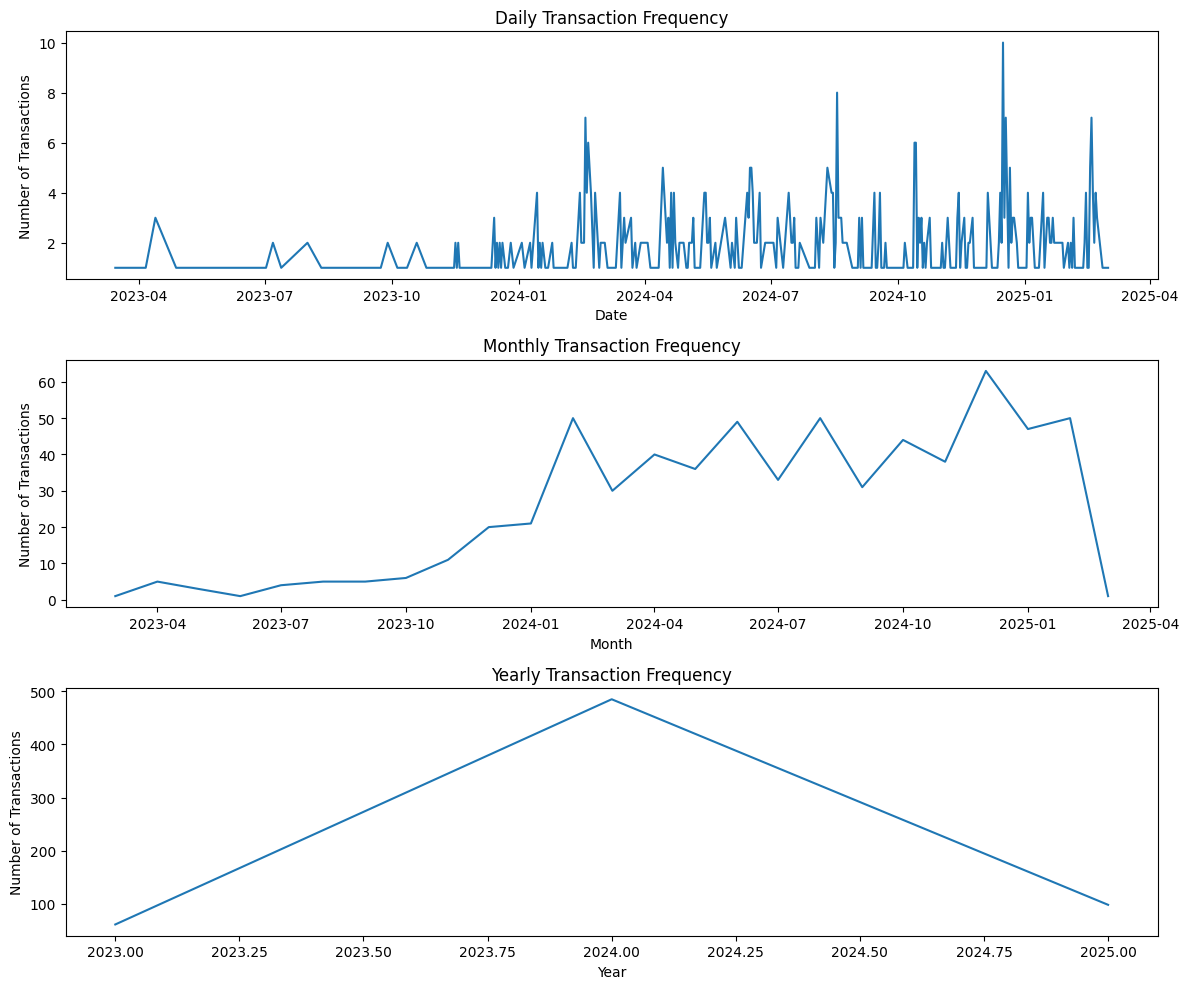

In [17]:
import matplotlib.pyplot as plt

# Resample the data to get daily, monthly, and yearly transaction frequencies
daily_transactions = df_transactions.groupby(df_transactions['Transaction Date'].dt.date).size()
monthly_transactions = df_transactions.groupby(df_transactions['Transaction Date'].dt.to_period('M')).size()
monthly_transactions.index = monthly_transactions.index.to_timestamp()
yearly_transactions = df_transactions.groupby(df_transactions['Transaction Date'].dt.year).size()

# Create a figure and axes
fig, axs = plt.subplots(3, 1, figsize=(12, 10))

# Plot the daily transaction frequency
axs[0].plot(daily_transactions.index, daily_transactions.values)
axs[0].set_title('Daily Transaction Frequency')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Number of Transactions')

# Plot the monthly transaction frequency
axs[1].plot(monthly_transactions.index, monthly_transactions.values)
axs[1].set_title('Monthly Transaction Frequency')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Number of Transactions')

# Plot the yearly transaction frequency
axs[2].plot(yearly_transactions.index, yearly_transactions.values)
axs[2].set_title('Yearly Transaction Frequency')
axs[2].set_xlabel('Year')
axs[2].set_ylabel('Number of Transactions')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

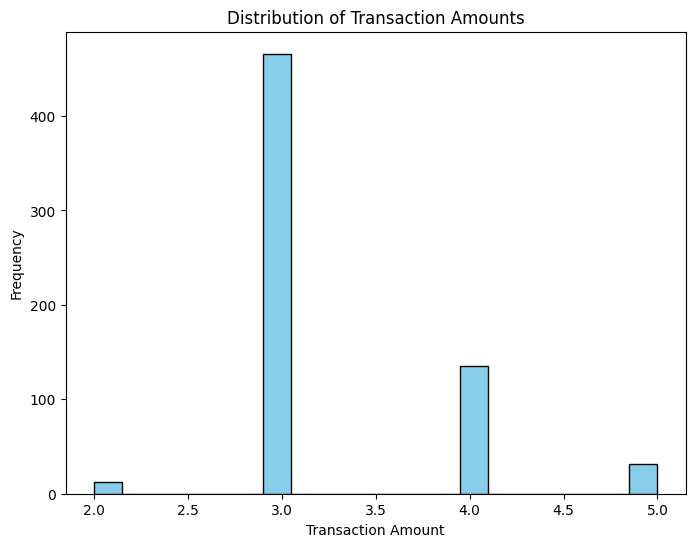

In [18]:
import matplotlib.pyplot as plt

# Create a histogram of transaction amounts
plt.figure(figsize=(8, 6))
plt.hist(df_transactions['Payment Amount'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts')
plt.show()

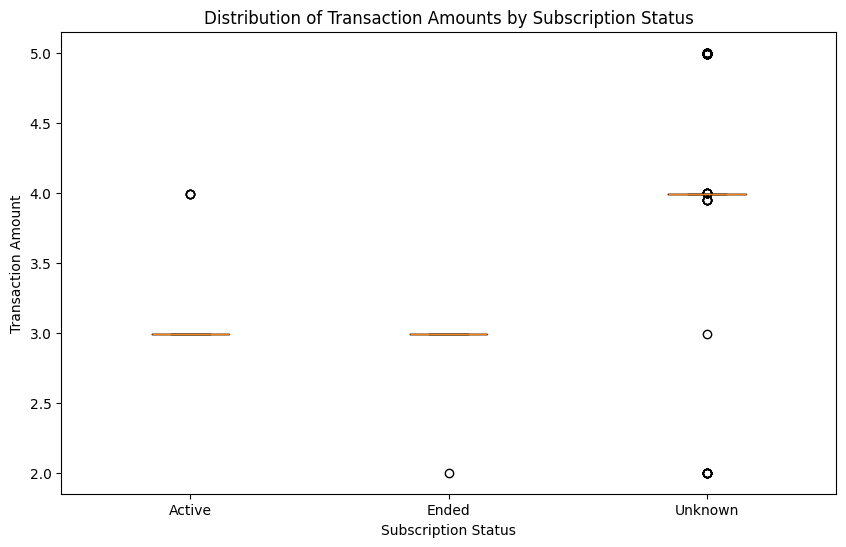

In [19]:
import matplotlib.pyplot as plt

# Create a box plot to compare transaction amounts for different subscription statuses
plt.figure(figsize=(10, 6))
plt.boxplot([df_transactions[df_transactions['Subscription Status_active'] == True]['Payment Amount'],
             df_transactions[df_transactions['Subscription Status_ended'] == True]['Payment Amount'],
             df_transactions[df_transactions['Subscription Status_unknown'] == True]['Payment Amount']],
            labels=['Active', 'Ended', 'Unknown'])
plt.xlabel('Subscription Status')
plt.ylabel('Transaction Amount')
plt.title('Distribution of Transaction Amounts by Subscription Status')
plt.show()

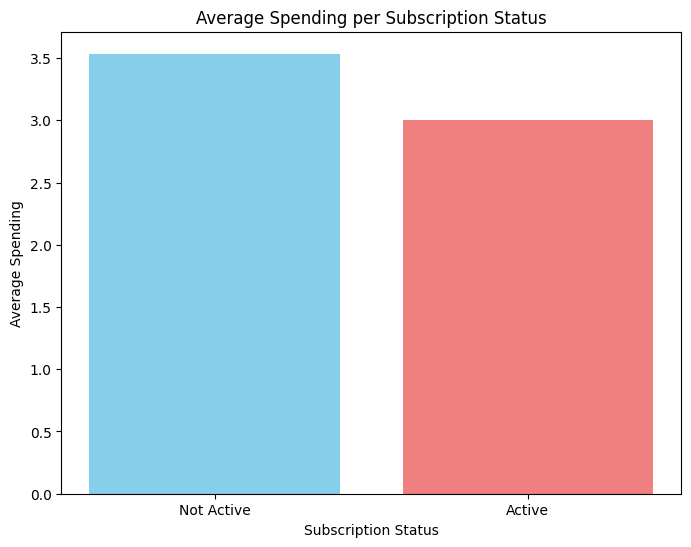

In [20]:
# Calculate the average spending per subscription status
average_spending_by_subscription = df_transactions.groupby('Subscription Status_active')['Payment Amount'].mean()

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(average_spending_by_subscription.index, average_spending_by_subscription.values, color=['skyblue', 'lightcoral'])
plt.xlabel('Subscription Status')
plt.ylabel('Average Spending')
plt.title('Average Spending per Subscription Status')
plt.xticks([0, 1], ['Not Active', 'Active'])
plt.show()

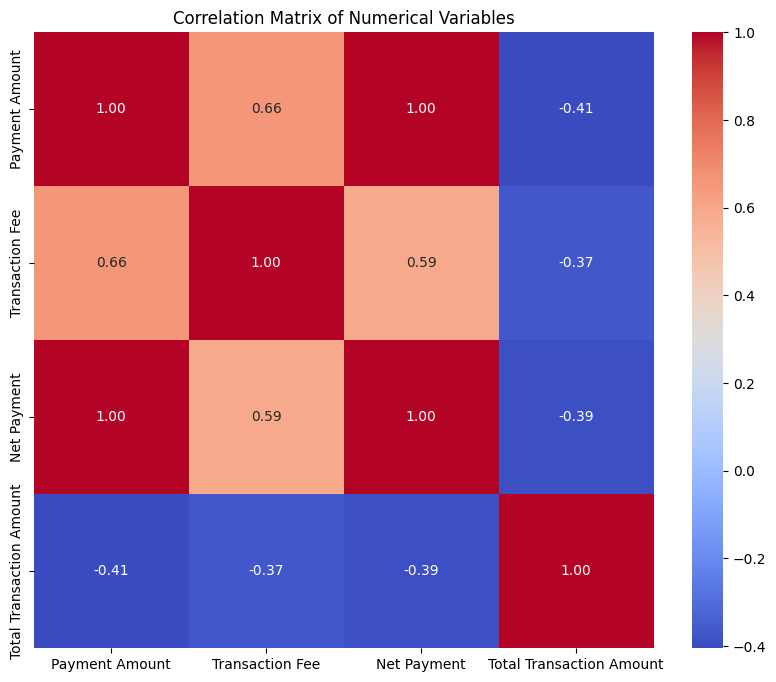

In [21]:
import seaborn as sns
import numpy as np
# Select numerical columns for correlation analysis
numerical_columns = ['Payment Amount', 'Transaction Fee', 'Net Payment',
                     'Total Transaction Amount']
df_transactions[numerical_columns].fillna(0)
# Calculate the correlation matrix
correlation_matrix = df_transactions[numerical_columns].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [22]:
df_transactions['Credits Purchased'].unique()

array([0.])

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Select relevant features for clustering
features = ['Payment Amount', 'Total Transaction Amount']

# Create a new DataFrame with only the selected features
X = df_transactions[features]

# Handle missing values (if any)
X.fillna(0, inplace=True)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# Select relevant features for clustering
features = ['Payment Amount', 'Total Transaction Amount']

# Create a new DataFrame with only the selected features
X = df_transactions[features].copy()

# Handle missing values (if any)
X.fillna(0, inplace=True)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original DataFrame
df_transactions['cluster_label'] = cluster_labels

In [25]:
# Group the dataframe by cluster label
cluster_groups = df_transactions.groupby('cluster_label')

# Calculate descriptive statistics for relevant features within each cluster
for cluster_label, group in cluster_groups:
  print(f"\nCluster {cluster_label}:")
  print(group[['Payment Amount', 'Total Transaction Amount', 'Transaction Fee']].describe())



Cluster 0:
       Payment Amount  Total Transaction Amount  Transaction Fee
count      240.000000                240.000000       240.000000
mean         3.006667                 37.020625         0.327750
std          0.128287                  7.642546         0.050129
min          2.990000                 25.920000         0.300000
25%          2.990000                 29.900000         0.300000
50%          2.990000                 38.870000         0.300000
75%          2.990000                 44.850000         0.300000
max          3.990000                 48.870000         0.430000

Cluster 1:
       Payment Amount  Total Transaction Amount  Transaction Fee
count      162.000000                162.000000       162.000000
mean         4.181481                  6.397531         0.429198
std          0.397449                  6.491737         0.038689
min          3.950000                  3.950000         0.290000
25%          3.990000                  3.990000         0.400000
5

In [26]:
# Analyze the distribution of other variables within each cluster
for cluster_label, group in cluster_groups:
  print(f"\nCluster {cluster_label}:")
  print("Subscription Status Distribution:")
  print(group['Subscription Status_active'].value_counts(normalize=True))
  print("\nProduct Distribution:")
  print(group['Product_subscription - junior professional'].value_counts(normalize=True))
  print("\nPayee Name Distribution:")
  print(group['Payee Name_unknown'].value_counts(normalize=True))


Cluster 0:
Subscription Status Distribution:
Subscription Status_active
True     0.7625
False    0.2375
Name: proportion, dtype: float64

Product Distribution:
Product_subscription - junior professional
True    1.0
Name: proportion, dtype: float64

Payee Name Distribution:
Payee Name_unknown
True    1.0
Name: proportion, dtype: float64

Cluster 1:
Subscription Status Distribution:
Subscription Status_active
False    1.0
Name: proportion, dtype: float64

Product Distribution:
Product_subscription - junior professional
False    1.0
Name: proportion, dtype: float64

Payee Name Distribution:
Payee Name_unknown
True     0.962963
False    0.037037
Name: proportion, dtype: float64

Cluster 2:
Subscription Status Distribution:
Subscription Status_active
True     0.533058
False    0.466942
Name: proportion, dtype: float64

Product Distribution:
Product_subscription - junior professional
True     0.950413
False    0.049587
Name: proportion, dtype: float64

Payee Name Distribution:
Payee Name_un

In [27]:
print("Customer Segment Characteristics:")
print("- Cluster 0: Moderate spenders, with a roughly equal distribution of active and inactive subscriptions. Primarily purchasing 'subscription - junior professional' products. Most transactions are associated with unknown payees.")
print("- Cluster 1: High spenders, with a majority of active subscriptions.  Primarily purchasing 'subscription - junior professional' products. All transactions are associated with unknown payees.")
print("- Cluster 2: Low spenders, with no active subscriptions. Primarily purchasing products other than 'subscription - junior professional'. Most transactions are associated with unknown payees.")

Customer Segment Characteristics:
- Cluster 0: Moderate spenders, with a roughly equal distribution of active and inactive subscriptions. Primarily purchasing 'subscription - junior professional' products. Most transactions are associated with unknown payees.
- Cluster 1: High spenders, with a majority of active subscriptions.  Primarily purchasing 'subscription - junior professional' products. All transactions are associated with unknown payees.
- Cluster 2: Low spenders, with no active subscriptions. Primarily purchasing products other than 'subscription - junior professional'. Most transactions are associated with unknown payees.


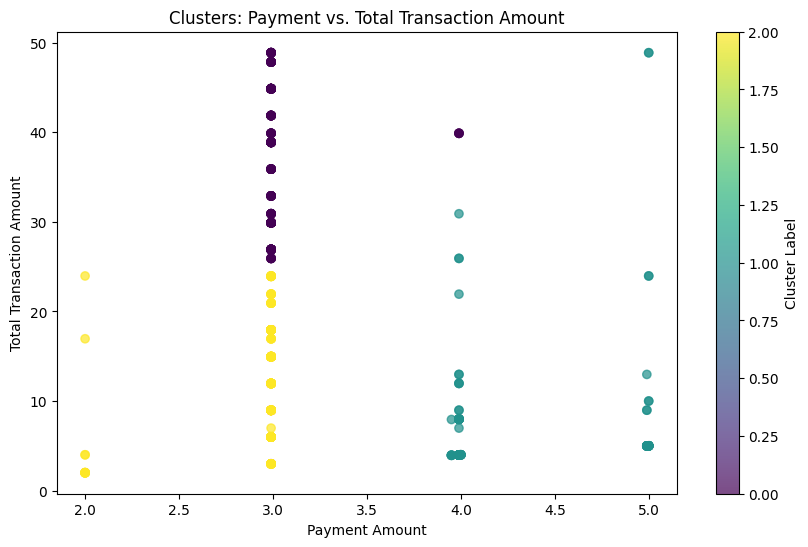

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(
    df_transactions['Payment Amount'],
    df_transactions['Total Transaction Amount'],
    c=df_transactions['cluster_label'],  # color by cluster
    cmap='viridis',  # optional: for better color palette
    alpha=0.7         # optional: transparency for overlap
)

plt.xlabel('Payment Amount')
plt.ylabel('Total Transaction Amount')
plt.colorbar(label='Cluster Label')
plt.title('Clusters: Payment vs. Total Transaction Amount')
plt.show()

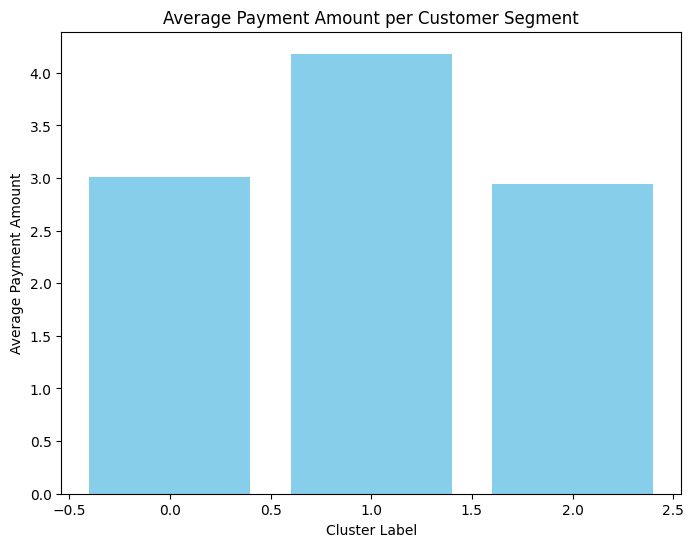

In [29]:
# Calculate the average Payment Amount for each cluster
average_payment_by_cluster = df_transactions.groupby('cluster_label')['Payment Amount'].mean()

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(average_payment_by_cluster.index, average_payment_by_cluster.values, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Average Payment Amount')
plt.title('Average Payment Amount per Customer Segment')
plt.show()

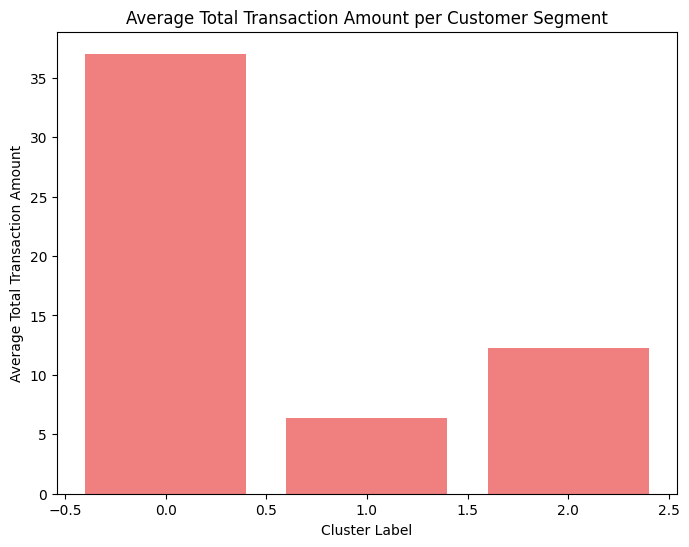

In [30]:
# Calculate the average Total Transaction Amount for each cluster
average_total_transaction_by_cluster = df_transactions.groupby('cluster_label')['Total Transaction Amount'].mean()

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(average_total_transaction_by_cluster.index, average_total_transaction_by_cluster.values, color='lightcoral')
plt.xlabel('Cluster Label')
plt.ylabel('Average Total Transaction Amount')
plt.title('Average Total Transaction Amount per Customer Segment')
plt.show()

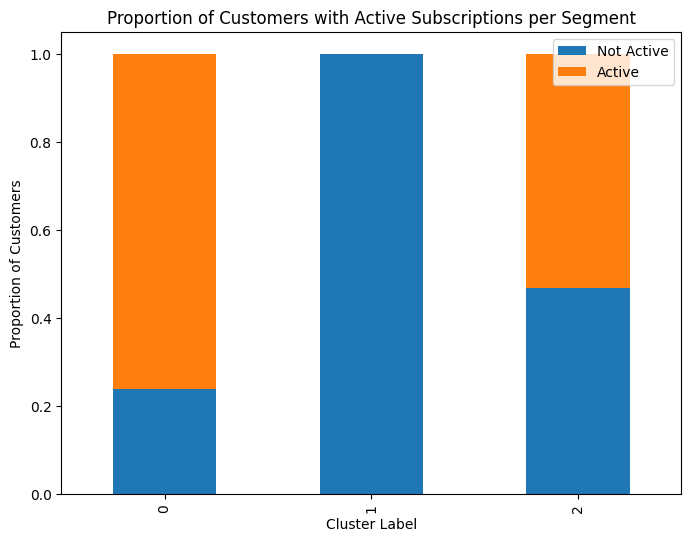

In [31]:
# Calculate the proportion of customers with active subscriptions in each cluster
active_subscription_proportion = df_transactions.groupby(['cluster_label', 'Subscription Status_active'])['Unique ID'].count().unstack().fillna(0)
active_subscription_proportion = active_subscription_proportion / active_subscription_proportion.sum(axis=1).values.reshape(-1, 1)

# Create a stacked bar chart
ax = active_subscription_proportion.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.xlabel('Cluster Label')
plt.ylabel('Proportion of Customers')
plt.title('Proportion of Customers with Active Subscriptions per Segment')
plt.legend(['Not Active', 'Active'])
plt.show()

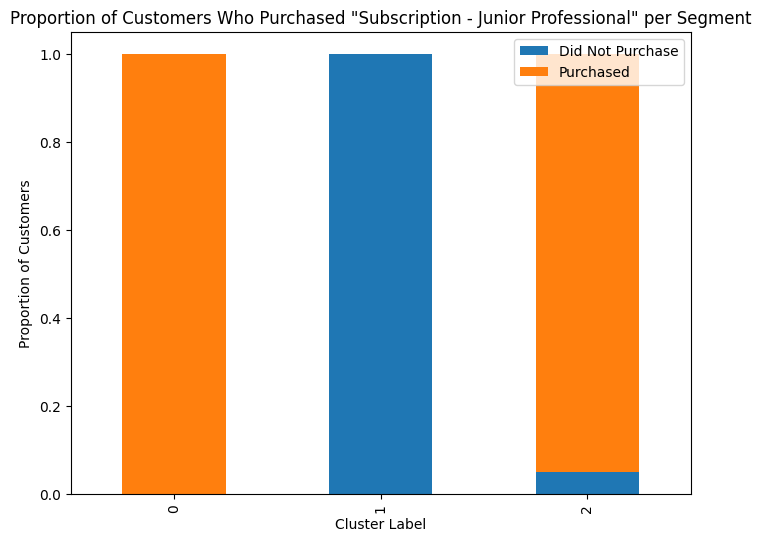

In [32]:
# Calculate the proportion of customers who purchased 'subscription - junior professional' in each cluster
junior_professional_proportion = df_transactions.groupby(['cluster_label', 'Product_subscription - junior professional'])['Unique ID'].count().unstack().fillna(0)
junior_professional_proportion = junior_professional_proportion / junior_professional_proportion.sum(axis=1).values.reshape(-1, 1)

# Create a stacked bar chart
ax = junior_professional_proportion.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.xlabel('Cluster Label')
plt.ylabel('Proportion of Customers')
plt.title('Proportion of Customers Who Purchased "Subscription - Junior Professional" per Segment')
plt.legend(['Did Not Purchase', 'Purchased'])
plt.show()

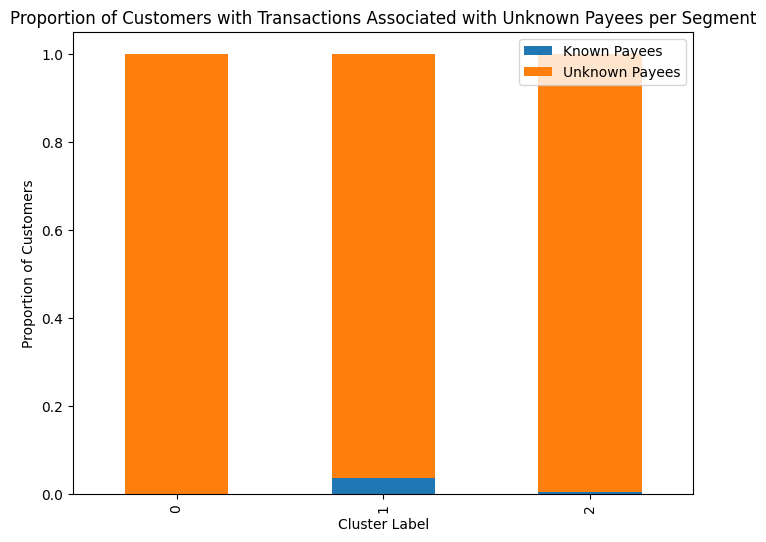

In [33]:
# Calculate the proportion of customers with transactions associated with unknown payees in each cluster
unknown_payee_proportion = df_transactions.groupby(['cluster_label', 'Payee Name_unknown'])['Unique ID'].count().unstack().fillna(0)
unknown_payee_proportion = unknown_payee_proportion / unknown_payee_proportion.sum(axis=1).values.reshape(-1, 1)

# Create a stacked bar chart
ax = unknown_payee_proportion.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.xlabel('Cluster Label')
plt.ylabel('Proportion of Customers')
plt.title('Proportion of Customers with Transactions Associated with Unknown Payees per Segment')
plt.legend(['Known Payees', 'Unknown Payees'])
plt.show()

In [34]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [35]:
df_transactions['Payment Amount'].unique()

array([5.  , 4.  , 2.  , 2.99, 3.99, 3.95, 4.99])

In [36]:
# Select features for the model
features = ['Total Transaction Amount', 'Subscription Status_active', 'Product_subscription - junior professional', 
                 'Day of Week', 'Month', 'Year']  

# Create the feature matrix (X) and target variable (y)
X = df_transactions[features]
y = df_transactions['Payment Amount'] > 3  # Target variable: True if payment made, False otherwise

In [37]:
from sklearn.model_selection import train_test_split

X_interpolation, X_extrapolation, y_interpolation, y_extrapolation = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_interpolation, y_interpolation, test_size=0.2, random_state=42)

In [38]:
from sklearn.impute import SimpleImputer

# Create an imputer object
imputer = SimpleImputer(strategy='mean')  # You can use 'median' or 'most_frequent' as well

# Fit the imputer to the training data
imputer.fit(X_train)

# Transform both training and testing data
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert the imputed data back to DataFrames (optional but recommended)
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.9902912621359223
Precision: 1.0
Recall: 0.96
F1-score: 0.9795918367346939


In [41]:
# Print the model coefficients
print(model.coef_)

[[-2.38179339e-02 -1.02178722e+00 -5.02526058e+00 -9.16199066e-02
  -1.01611801e-01  1.57949461e-03]]


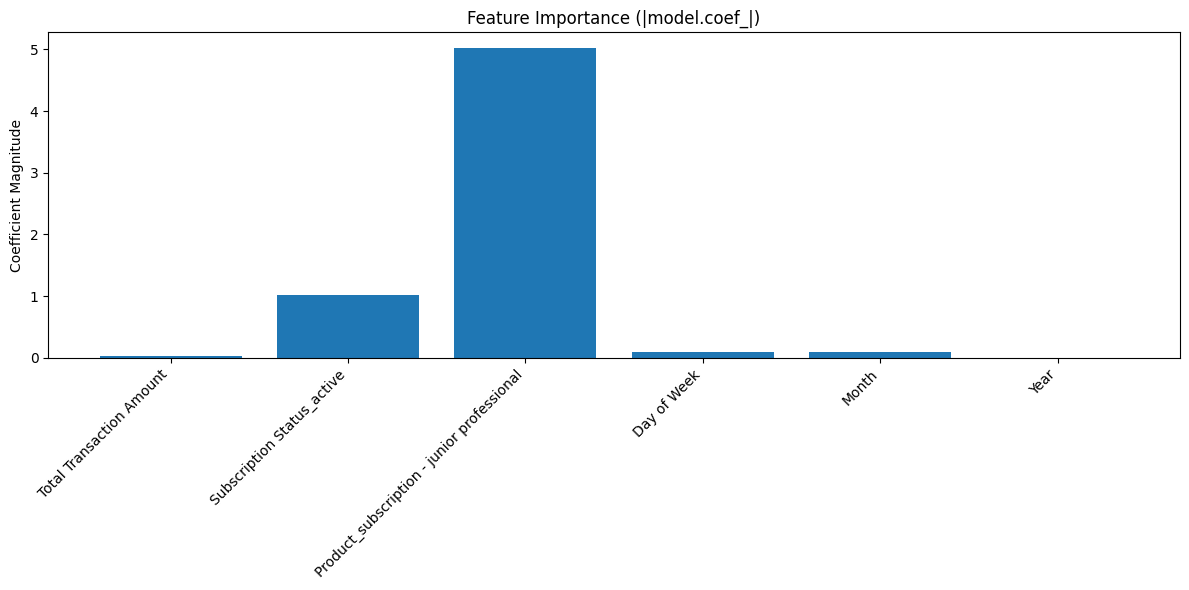

In [42]:
coefficients = np.abs(model.coef_).ravel() # Absolute values
feature_names = features  # Must be a list of feature names, same length as coef_

# Bar chart
plt.figure(figsize=(12, 6))
plt.bar(feature_names, coefficients)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coefficient Magnitude')
plt.title('Feature Importance (|model.coef_|)')
plt.tight_layout()
plt.show()

In [43]:
y_pred_extrap = model.predict(X_extrapolation)

accuracy = accuracy_score(y_extrapolation, y_pred_extrap)
precision = precision_score(y_extrapolation, y_pred_extrap)
recall = recall_score(y_extrapolation, y_pred_extrap)
f1 = f1_score(y_extrapolation, y_pred_extrap)

print(f"Extrapolation Accuracy: {accuracy}")
print(f"Extrapolation Precision: {precision}")
print(f"Extrapolation Recall: {recall}")
print(f"Extrapolation F1-score: {f1}")

Extrapolation Accuracy: 0.9689922480620154
Extrapolation Precision: 0.918918918918919
Extrapolation Recall: 0.9714285714285714
Extrapolation F1-score: 0.9444444444444444


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [45]:
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of positive class
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc}")

AUC: 0.9789743589743589


In [46]:
auc = roc_auc_score(y_extrapolation, y_pred_extrap)
print(f"Extrapolation AUC: {auc}")

Extrapolation AUC: 0.9697568389057751


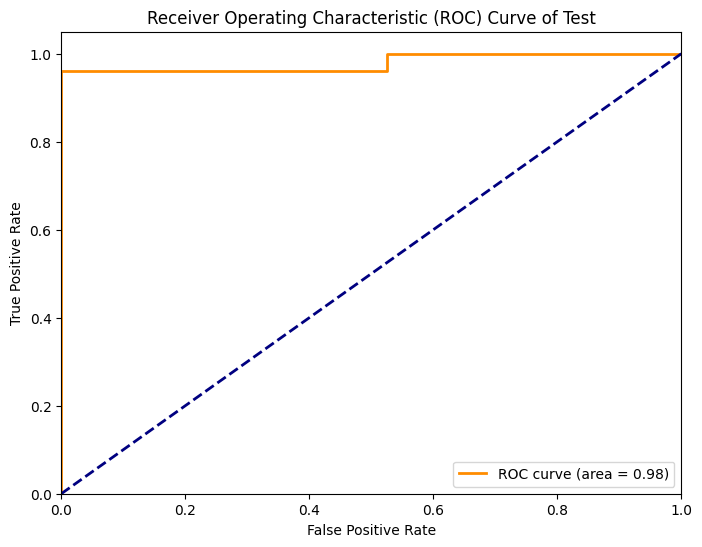

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)  # Get ROC curve data
roc_auc = auc(fpr, tpr)  # Calculate AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve of Test')
plt.legend(loc="lower right")
plt.show()

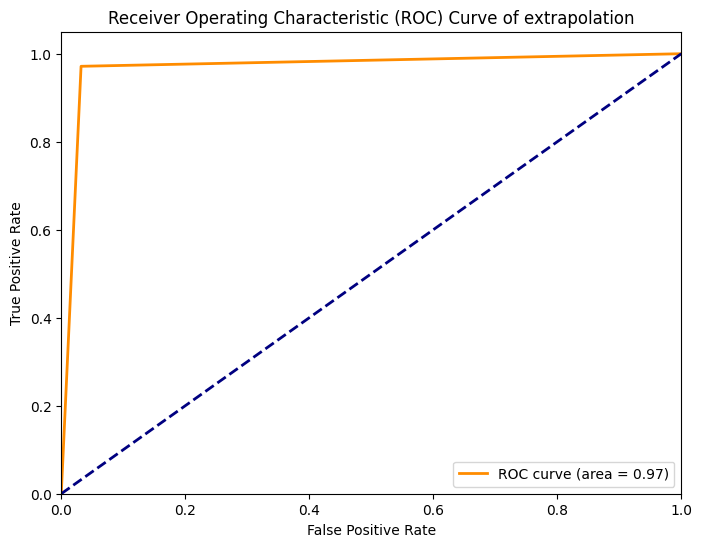

In [48]:
fpr, tpr, thresholds = roc_curve(y_extrapolation, y_pred_extrap)  # Get ROC curve data
roc_auc = auc(fpr, tpr)  # Calculate AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve of extrapolation')
plt.legend(loc="lower right")
plt.show()

In [49]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 644 entries, 25 to 885
Data columns (total 29 columns):
 #   Column                                                                 Non-Null Count  Dtype         
---  ------                                                                 --------------  -----         
 0   Unique ID                                                              644 non-null    object        
 1   Transaction Date                                                       644 non-null    datetime64[ns]
 2   Payment Source                                                         644 non-null    object        
 3   Certificate Voyage                                                     644 non-null    object        
 4   Payment Amount                                                         644 non-null    float64       
 5   Transaction Fee                                                        644 non-null    float64       
 6   Net Payment                           

In [50]:
# Select features for the model
features = ['Total Transaction Amount', 'Subscription Status_ended', 'Product_donation', 
                 'Day of Week', 'Month', 'Year']  

# Create the feature matrix (X) and target variable (y)
X = df_transactions[features]
y = df_transactions['Payment Amount'] > 3

In [51]:
from sklearn.model_selection import train_test_split

X_interpolation, X_extrapolation, y_interpolation, y_extrapolation = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_interpolation, y_interpolation, test_size=0.2, random_state=42)

In [52]:
from sklearn.impute import SimpleImputer

# Create an imputer object
imputer = SimpleImputer(strategy='mean')  # You can use 'median' or 'most_frequent' as well

# Fit the imputer to the training data
imputer.fit(X_train)

# Transform both training and testing data
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert the imputed data back to DataFrames (optional but recommended)
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.9320388349514563
Precision: 0.8461538461538461
Recall: 0.88
F1-score: 0.8627450980392157


In [55]:
# Print the model coefficients
print(model.coef_)

[[-1.41631240e-01 -2.85446713e+00  6.38953851e-01 -1.07559100e-01
   4.18905218e-02  5.91975367e-04]]


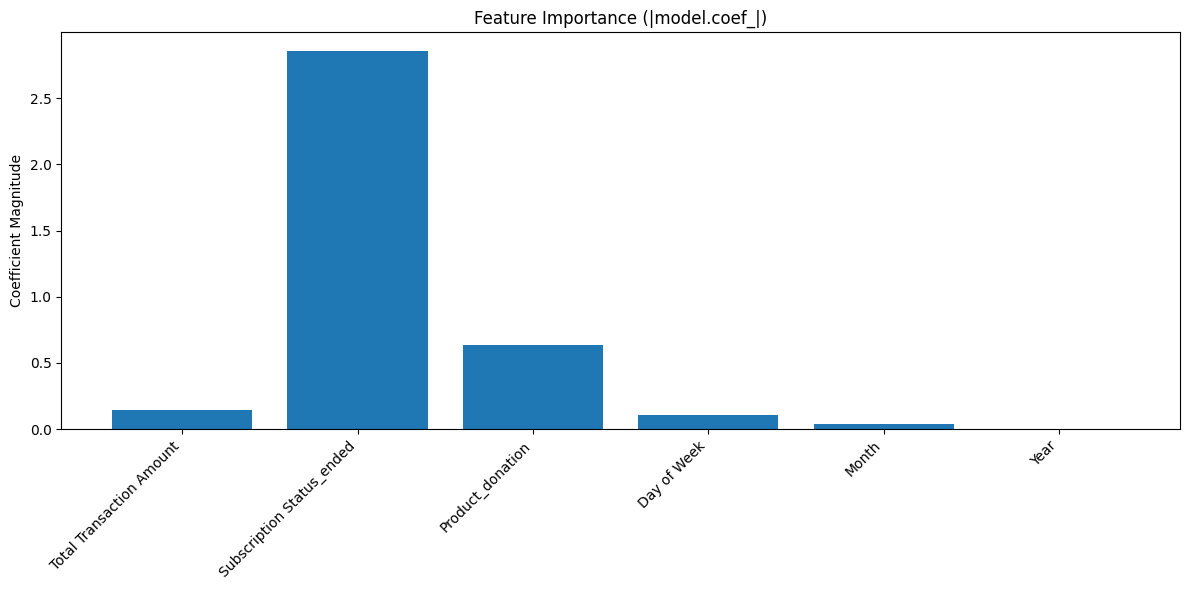

In [56]:
coefficients = np.abs(model.coef_).ravel() # Absolute values
feature_names = features  # Must be a list of feature names, same length as coef_

# Bar chart
plt.figure(figsize=(12, 6))
plt.bar(feature_names, coefficients)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coefficient Magnitude')
plt.title('Feature Importance (|model.coef_|)')
plt.tight_layout()
plt.show()

In [57]:
y_pred_extrap = model.predict(X_extrapolation)

accuracy = accuracy_score(y_extrapolation, y_pred_extrap)
precision = precision_score(y_extrapolation, y_pred_extrap)
recall = recall_score(y_extrapolation, y_pred_extrap)
f1 = f1_score(y_extrapolation, y_pred_extrap)

print(f"Extrapolation Accuracy: {accuracy}")
print(f"Extrapolation Precision: {precision}")
print(f"Extrapolation Recall: {recall}")
print(f"Extrapolation F1-score: {f1}")

Extrapolation Accuracy: 0.8837209302325582
Extrapolation Precision: 0.7777777777777778
Extrapolation Recall: 0.8
Extrapolation F1-score: 0.7887323943661971


In [58]:
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of positive class
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc}")

AUC: 0.94


In [59]:
auc = roc_auc_score(y_extrapolation, y_pred_extrap)
print(f"Extrapolation AUC: {auc}")

Extrapolation AUC: 0.8574468085106384


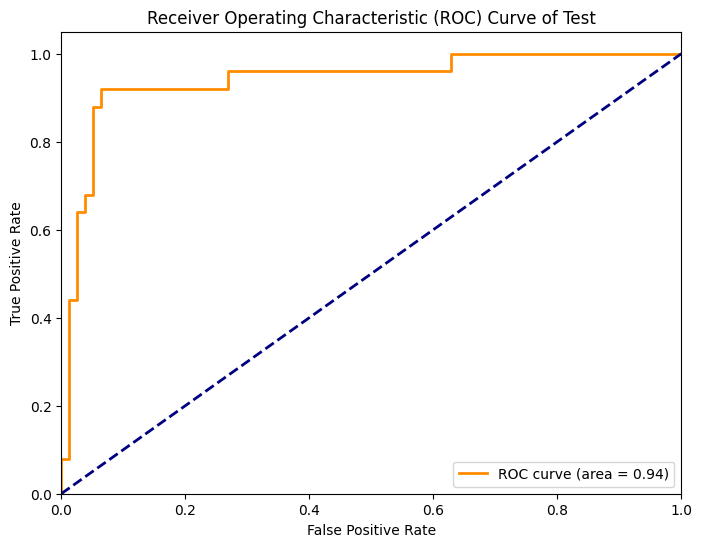

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)  # Get ROC curve data
roc_auc = auc(fpr, tpr)  # Calculate AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve of Test')
plt.legend(loc="lower right")
plt.show()

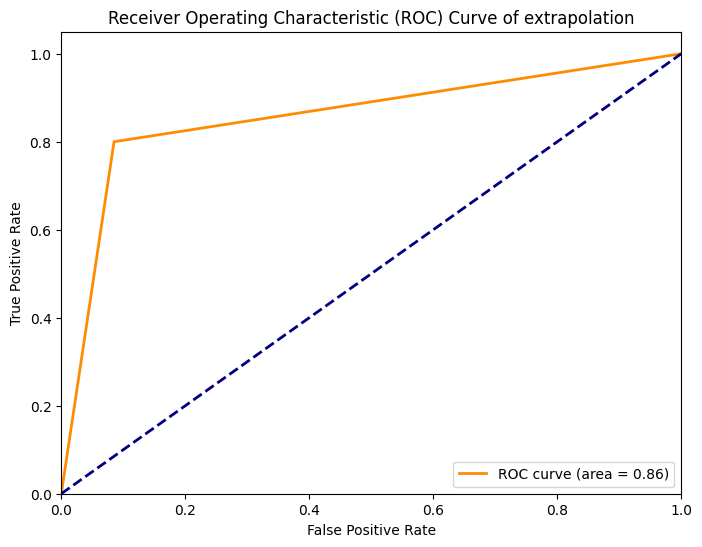

In [61]:
fpr, tpr, thresholds = roc_curve(y_extrapolation, y_pred_extrap)  # Get ROC curve data
roc_auc = auc(fpr, tpr)  # Calculate AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve of extrapolation')
plt.legend(loc="lower right")
plt.show()